In [1]:
import numpy as np
import pandas as pd

In [2]:
courses = pd.read_csv('./session20datasets/courses.csv')
students = pd.read_csv('./session20datasets/students.csv')
nov = pd.read_csv('./session20datasets/reg-month1.csv')
dec = pd.read_csv('./session20datasets/reg-month2.csv')

matches = pd.read_csv('./session20datasets/matches.csv')
delivery = pd.read_csv('./session20datasets/deliveries.csv')

In [3]:
courses

,course_id,course_name,price
0,1,python,2499
1,2,sql,3499
2,3,data analysis,4999
3,4,machine learning,9999
4,5,tableau,2499
5,6,power bi,1899
6,7,ms sxcel,1599
7,8,pandas,1099
8,9,plotly,699
9,10,pyspark,2499


In [4]:
nov

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [5]:
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


## pd.concat

In [6]:
pd.concat([nov,dec])

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


## ignore index

In [7]:
regs=pd.concat([nov,dec],ignore_index=True)
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


append

## multiindexing

In [8]:
multi=pd.concat([nov,dec],keys=["nov","dec"])
multi

student_id  course_id
nov 0           23          1
    1           15          5
    2           18          6
    3           23          4
    4           16          9
    5           18          1
    6            1          1
    7            7          8
    8           22          3
    9           15          1
    10          19          4
    11           1          6
    12           7         10
    13          11          7
    14          13          3
    15          24          4
    16          21          1
    17          16          5
    18          23          3
    19          17          7
    20          23          6
    21          25          1
    22          19          2
    23          25         10
    24           3          3
dec 0            3          5
    1           16          7
    2           12         10
    3           12          1
    4           14          9
    5            7          7
    6            7          2
    7           16          3
    8           17         10
    9           11          8
    10          14          6
    11          12          5
    12          12          7
    13          18          8
    14           1         10
    15           1          9
    16           2          5
    17           7          6
    18          22          5
    19          22          6
    20          23          9
    21          23          5
    22          14          4
    23          14          1
    24          11         10
    25          42          9
    26          50          8
    27          38          1

In [9]:
multi.loc["nov"]

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [10]:
multi.loc[("dec",4)]

student_id    14
course_id      9
Name: (dec, 4), dtype: int64

In [11]:
pd.concat([nov,dec],axis=1)

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


## inner join is like a intersection

In [12]:
students.merge(regs,how="inner",on="student_id")

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


## inner joins joins according to the commoon columns 

## left joins

In [13]:
students.merge(regs,how="left")

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1.0
1,1,Kailash Harjo,23,6.0
2,1,Kailash Harjo,23,10.0
3,1,Kailash Harjo,23,9.0
4,2,Esha Butala,1,5.0
5,3,Parveen Bhalla,3,3.0
6,3,Parveen Bhalla,3,5.0
7,4,Marlo Dugal,14,NaN
8,5,Kusum Bahri,6,NaN
9,6,Lakshmi Contractor,10,NaN


## right joins

In [14]:
students.merge(regs,how="right",on="student_id")

,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


In [15]:
students.head(1)

,student_id,name,partner
0,1,Kailash Harjo,23


In [16]:
regs.head(1)

,student_id,course_id
0,23,1


## if we dont give like 0n="common columns " then pandas automatically joins or merge using a common columns if common columns doesnt exist than it will raise an error 

## outer join

In [17]:
students.merge(regs,how="outer")

,student_id,name,partner,course_id
0,1,Kailash Harjo,23.0,1.0
1,1,Kailash Harjo,23.0,6.0
2,1,Kailash Harjo,23.0,10.0
3,1,Kailash Harjo,23.0,9.0
4,2,Esha Butala,1.0,5.0
5,3,Parveen Bhalla,3.0,3.0
6,3,Parveen Bhalla,3.0,5.0
7,4,Marlo Dugal,14.0,NaN
8,5,Kusum Bahri,6.0,NaN
9,6,Lakshmi Contractor,10.0,NaN


In [18]:
# right join
temp_df = pd.DataFrame({
    'student_id':[26,27,28],
    'name':['Nitish','Ankit','Rahul'],
    'partner':[28,26,17]
})

students = pd.concat([students,temp_df],ignore_index=True)

In [19]:
students.merge(regs,how="outer").tail(10)

,student_id,name,partner,course_id
53,23,Chhavi Lachman,18.0,5.0
54,24,Radhika Suri,17.0,4.0
55,25,Shashank D’Alia,2.0,1.0
56,25,Shashank D’Alia,2.0,10.0
57,26,Nitish,28.0,NaN
58,27,Ankit,26.0,NaN
59,28,Rahul,17.0,NaN
60,38,NaN,NaN,1.0
61,42,NaN,NaN,9.0
62,50,NaN,NaN,8.0


## find the total number generated 

In [20]:
regs.merge(courses,how="inner")["price"].sum()

np.int64(154247)

## find month by month revenue

In [21]:
temp=pd.concat([nov,dec],keys=["nov","dec"]).reset_index()
temp

,level_0,level_1,student_id,course_id
0,nov,0,23,1
1,nov,1,15,5
2,nov,2,18,6
3,nov,3,23,4
4,nov,4,16,9
5,nov,5,18,1
6,nov,6,1,1
7,nov,7,7,8
8,nov,8,22,3
9,nov,9,15,1


In [22]:
merge=temp.merge(courses)
merge

,level_0,level_1,student_id,course_id,course_name,price
0,nov,0,23,1,python,2499
1,nov,1,15,5,tableau,2499
2,nov,2,18,6,power bi,1899
3,nov,3,23,4,machine learning,9999
4,nov,4,16,9,plotly,699
5,nov,5,18,1,python,2499
6,nov,6,1,1,python,2499
7,nov,7,7,8,pandas,1099
8,nov,8,22,3,data analysis,4999
9,nov,9,15,1,python,2499


In [23]:
merge.groupby("level_0")["price"].sum()

level_0
dec    65072
nov    89175
Name: price, dtype: int64

## print the registration table 
## cols name,courses ,price

In [24]:
regs.head(1)


,student_id,course_id
0,23,1


In [25]:
students.head(1)

,student_id,name,partner
0,1,Kailash Harjo,23


In [26]:
courses.head(1)

,course_id,course_name,price
0,1,python,2499


In [27]:
merge1=students.merge(regs,how="inner")
merge1

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [28]:
merge2=merge1.merge(courses,how="inner")
merge2

,student_id,name,partner,course_id,course_name,price
0,1,Kailash Harjo,23,1,python,2499
1,1,Kailash Harjo,23,6,power bi,1899
2,1,Kailash Harjo,23,10,pyspark,2499
3,1,Kailash Harjo,23,9,plotly,699
4,2,Esha Butala,1,5,tableau,2499
5,3,Parveen Bhalla,3,3,data analysis,4999
6,3,Parveen Bhalla,3,5,tableau,2499
7,7,Tarun Thaker,9,8,pandas,1099
8,7,Tarun Thaker,9,10,pyspark,2499
9,7,Tarun Thaker,9,7,ms sxcel,1599


In [29]:
merge2.head(1)

,student_id,name,partner,course_id,course_name,price
0,1,Kailash Harjo,23,1,python,2499


In [30]:
merge2[["name","course_name","price"]]

,name,course_name,price
0,Kailash Harjo,python,2499
1,Kailash Harjo,power bi,1899
2,Kailash Harjo,pyspark,2499
3,Kailash Harjo,plotly,699
4,Esha Butala,tableau,2499
5,Parveen Bhalla,data analysis,4999
6,Parveen Bhalla,tableau,2499
7,Tarun Thaker,pandas,1099
8,Tarun Thaker,pyspark,2499
9,Tarun Thaker,ms sxcel,1599


## if we donot give how="join_name" then it default use inner join

In [31]:
# 3. Print the registration table
# cols -> name -> course -> price
regs.merge(students,on='student_id').merge(courses,on='course_id')[['name','course_name','price']]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


## plot bar chart for revenue/courses

In [32]:
regs.head(1)

,student_id,course_id
0,23,1


In [33]:
students.head(1)

,student_id,name,partner
0,1,Kailash Harjo,23


In [34]:
courses.head(1)

,course_id,course_name,price
0,1,python,2499


<Axes: xlabel='course_name'>

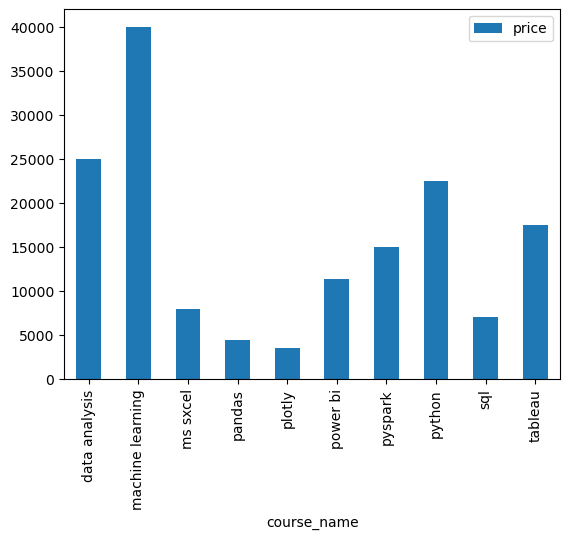

In [35]:
regs.merge(courses)[["course_name","price"]].groupby("course_name").sum().plot(kind="bar")

## find the students who enrolled in both the months

In [36]:


common_id=np.intersect1d(nov["student_id"], dec["student_id"])
common_id


array([ 1,  3,  7, 11, 16, 17, 18, 22, 23])

In [37]:
students[students["student_id"].isin(common_id)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


## find courses that got no enrollment

In [38]:
coursesi = courses[~courses["course_id"].isin(regs["course_id"])]

## using diff1d

In [39]:
not_enrolled=np.setdiff1d(courses["course_id"],regs["course_id"])
not_enrolled

array([11, 12])

In [40]:
courses[courses["course_id"]==not_enrolled]

ValueError: ('Lengths must match to compare', (12,), (2,))

## find the students that got no enrollment 

In [ ]:
not_enrolled_students=np.setdiff1d(students["student_id"],regs["student_id"])
not_enrolled_students

In [ ]:
students[students["student_id"].isin(not_enrolled_students)]

## find the course that got no enrollment 

In [ ]:
not_enroll_courses=np.setdiff1d(courses["course_id"],regs["course_id"])


In [ ]:
courses

In [ ]:
courses[courses["course_id"]==not_enroll_courses]

## print students name partner name  for all enroll students 

In [ ]:

#self join , join the table with itself
students.merge(students,how="inner",left_on="partner",right_on="student_id")[["name_x","name_y"]]

## find the top3 students who got most enrollment 

In [ ]:
regs.merge(students,on="student_id").groupby(["student_id","name"])["name"].count().sort_values(ascending=False)

## find the top 3 studnets who spend most of the money 

In [ ]:
regs.merge(students)

## find the students who spend the most money

In [ ]:
courses.head(1)

In [ ]:
courses

In [ ]:
courses = pd.read_csv('./session20datasets/courses.csv')
courses

In [ ]:
regs.merge(students).merge(courses).groupby(["student_id","name"])["price"].sum().sort_values(ascending=False)

In [ ]:
## alternate syntax for merge 
pd.merge(students,regs)

## ipl problems

## find the top 3 stadium with the highest sixes/match ratio

In [42]:
matches.head(1)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN


In [45]:
matches.groupby("venue")["

In [46]:
delivery.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [49]:
ipl_merge=matches.merge(delivery,left_on="id",right_on="match_id")

In [60]:
six=ipl_merge[ipl_merge["batsman_runs"]==6]
six.head(1)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
10,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,...,0,0,0,0,6,0,6,NaN,NaN,NaN


In [73]:
run_sixes=six.groupby("venue")["venue"].count()
run_sixes

venue
Barabati Stadium                                         68
Brabourne Stadium                                       114
Buffalo Park                                             27
De Beers Diamond Oval                                    34
Dr DY Patil Sports Academy                              173
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium     129
Dubai International Cricket Stadium                      58
Eden Gardens                                            594
Feroz Shah Kotla                                        636
Green Park                                               36
Himachal Pradesh Cricket Association Stadium            108
Holkar Cricket Stadium                                   88
JSCA International Stadium Complex                       76
Kingsmead                                               130
M Chinnaswamy Stadium                                   873
MA Chidambaram Stadium, Chepauk                         507
Maharashtra Cricket Association St

In [65]:
ipl_merge.head(1)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [74]:
total_matches=matches["venue"].value_counts()
total_matches

venue
M Chinnaswamy Stadium                                   66
Eden Gardens                                            61
Feroz Shah Kotla                                        60
Wankhede Stadium                                        57
Rajiv Gandhi International Stadium, Uppal               49
MA Chidambaram Stadium, Chepauk                         48
Punjab Cricket Association Stadium, Mohali              35
Sawai Mansingh Stadium                                  33
Dr DY Patil Sports Academy                              17
Subrata Roy Sahara Stadium                              17
Maharashtra Cricket Association Stadium                 15
Kingsmead                                               15
Sardar Patel Stadium, Motera                            12
SuperSport Park                                         12
Brabourne Stadium                                       11
Punjab Cricket Association IS Bindra Stadium, Mohali    11
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadiu

In [77]:
ratio=run_sixes/total_matches
ratio.sort_values(ascending=False).head(3)

venue
Holkar Cricket Stadium     17.600000
M Chinnaswamy Stadium      13.227273
Sharjah Cricket Stadium    12.666667
dtype: float64

## find the orange cap holders of all ipl seasons

## organe cap holder is that guy who makes more runs in the ipl seasons

In [94]:
ipl_merge.groupby(["season","batsman"])["batsman_runs"].sum().reset_index().sort_values("batsman_runs",ascending=False).drop_duplicates(subset=["season"],keep="first").sort_values("season")

,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641


In [81]:
delivery.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
